In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)

In [2]:
m, n = 40, 10
x = np.linspace(0, 1, m, endpoint=False)
mu = np.linspace(0, 1, n, endpoint=False)

In [3]:
def plot_paramspace(X):
    fig, ax = plt.subplots()
    plt.imshow(X, interpolation="none")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    plt.show()
    return fig, ax

In [4]:
def bump(x, mu):
    w = 2
    y = np.zeros_like(x)
    i = np.argmin(np.abs(x-mu))
    y[(i-w):(i+w-1)] = 1.0
    return y

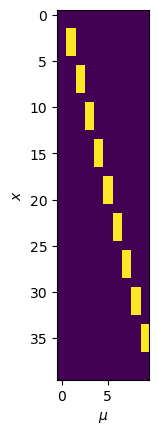

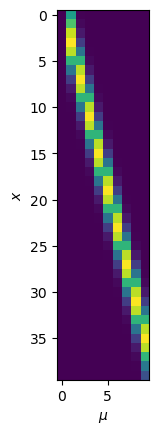

In [5]:
X = np.zeros((m, n))
X_c = np.zeros_like(X)
for j, mu_j in enumerate(mu):
    y = bump(x, mu_j)
    X[:, j] = y
    X_c[:, j] = gaussian_filter1d(y, 2)
plot_paramspace(X)
plt.show()
plot_paramspace(X_c)
plt.show()

In [6]:
U, S, VT = np.linalg.svd(X, False)
U_c, S_c, VT_c = np.linalg.svd(X_c, False)

In [7]:
def predict(VT, r, xi):
    method = "linear"
    V_interpolated = np.zeros((r, 1))
    for mode in range(r):
        interpolator = interp1d(mu, VT[mode, :], kind=method)
        V_interpolated[mode] = interpolator(xi)
    return V_interpolated

In [8]:
grid = [mu,]

In [9]:
VT_intp = predict(VT, 10, 0.35)
X_intp = (U*S) @ VT_intp

VT_intp_c = predict(VT_c, 10, 0.35)
X_intp_c = (U_c*S_c) @ VT_intp_c

Text(0, 0.5, 'y')

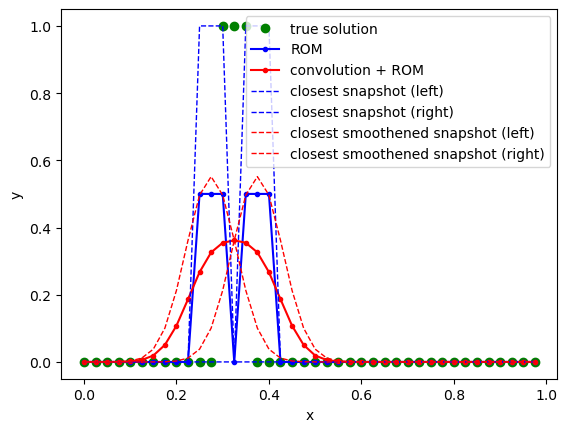

In [10]:
plt.plot(x, bump(x, 0.35), "go", label="true solution")
plt.plot(x, X_intp[:, 0], "b.-", label="ROM")
plt.plot(x, X_intp_c[:, 0], "r.-", label="convolution + ROM")

plt.plot(x, X[:, 3], "b--", lw=1, label="closest snapshot (left)")
plt.plot(x, X[:, 4], "b--", lw=1, label="closest snapshot (right)")

plt.plot(x, X_c[:, 3], "r--", lw=1, label="closest smoothened snapshot (left)")
plt.plot(x, X_c[:, 4], "r--", lw=1, label="closest smoothened snapshot (right)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

Text(0, 0.5, 'y')

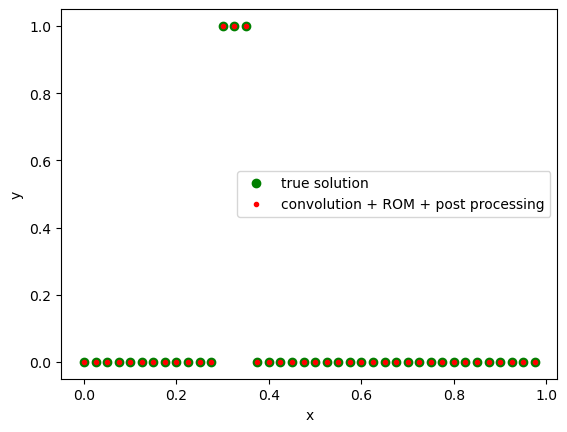

In [11]:
# physics informed post processing. Here: find largest 3 elements.
# other options: wiener deconvolution, threshold methods, ... 

ind = np.argpartition(X_intp_c[:, 0], -3)[-3:]
X_intp_c_post = np.zeros_like(X_intp_c)
X_intp_c_post[ind, 0] = 1
plt.plot(x, bump(x, 0.35), "go", label="true solution")
plt.plot(x, X_intp_c_post[:, 0], "r.", label="convolution + ROM + post processing")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")